In [ ]:
from common_functions import reduce
from astropy.io import fits
from astropy.modeling.fitting import LinearLSQFitter
from astropy.modeling.models import Linear1D
from astropy.table import Table
import astropy.units as u
import lightkurve as lk
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
from pyasassn.client import SkyPatrolClient


In [2]:
wlmodel = Linear1D()
linfitter = LinearLSQFitter()

In [3]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [4]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

## Stars for analysis:
### 1. TIC 201574467 / ASAS-SN ID 120259710279
#### -- a Cepheid W-Virginis Type variable from the VCX (period of 9.1521), while we predicted a  period of 9.266774 (err of 1.886173)
### 2. TIC 220338773 / ASAS-SN ID 188979496756
#### -- YSO variable from the VCX (period of 5.8208)(YSO)  while we predicted a period of 5.95914 (error of 2.385752)
### 3. TIC 6129951 / ASAS-SN ID 283468756785
#### -- a ROT variable from the VCX (period of 7.7504), while we predicted a period of 8.108467 (error of 1.677834)
### 4. TIC 440850419 / ASAS-SN ID 317828511249
#### -- a EB-Algol Type variable from the VCX (period of 3.7858), while we predicted a period of 7.04373 (error of 2.838802)


In [5]:
tmin = 2458485
tmax = 2460311
lcholder = client.query_list([283468756785, 188979496756, 317828511249, 120259710279], download=True)
# 1. Cepheid, 2. YSO, 3. ROT, 4. EB/EA

lcs = []
fluxes=[]
errors=[]
dates=[]

for lc in lcholder.itercurves():
    lctemp = lc
    lctemp = reduce(lctemp)
    
    fluxeswunitt = u.Quantity(lctemp.flux, unit='mJy')
    errswunitt = u.Quantity(lctemp.flux_err, unit='mJy')
    datest = u.Quantity(lctemp.jd, unit='d')
    
    lcs.append(lctemp)
    fluxes.append(fluxeswunitt)
    errors.append(errswunitt)
    dates.append(datest)

Pulled 4 of 4


In [6]:
os.chdir('files/tesslcs')

# 1. Cepheid

In [7]:
# ASAS-SN LC
lc = lk.LightCurve(time=dates[0], flux = fluxes[0], flux_err=errors[0])
lcnormed = lc.normalize().remove_outliers()

In [8]:
with fits.open("TIC201574467-CEP/hlsp_qlp_tess_ffi_s0057-0000000201574467_tess_v01_llc.fits") as hdul:
    cepheid = Table.read(hdul, format='fits').to_pandas()

In [9]:
cepheidfl = cepheid['SAP_FLUX']
cepheidday = cepheid['TIME']
tesslc = lk.LightCurve(time=cepheidday, flux = cepheidfl).normalize()

### The actual light curve seems to have some off-pixel effects. Let's divide out by that trend

In [10]:
cepheiddayline = cepheid['TIME']
xaxis = cepheiddayline
linfit_wlmodel = linfitter(model=wlmodel, x=[2857.3082978758953, 2867.11395, 2877.037564] , y=[1.1902518272399902, 1.164912, 1.16181635])
wavelengths = linfit_wlmodel(xaxis)
linfit_wlmodel

<Linear1D(slope=-0.00143902, intercept=5.29821727)>

Text(0.5, 0, 'Time [BJD-2457000]')

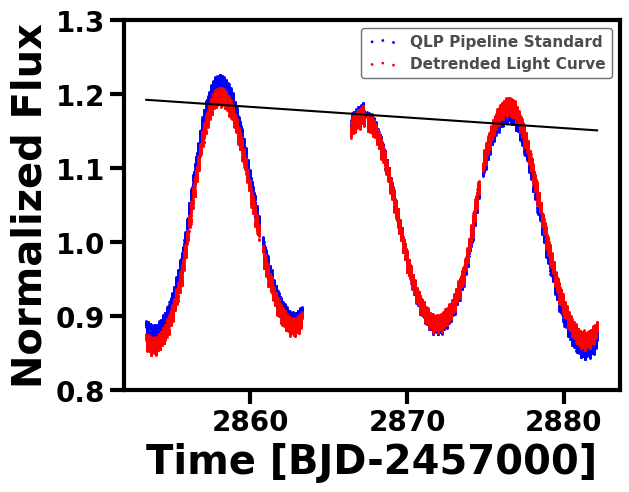

In [11]:
fig, ax = plt.subplots(1, 1)
fluxnew = cepheidfl/linfit_wlmodel(xaxis)
tesslc2 = lk.LightCurve(time=cepheidday, flux = fluxnew).normalize()

tesslc.scatter(ax=ax, c='b', label='QLP Pipeline Standard')
tesslc2.scatter(ax=ax, c='r', label='Detrended Light Curve')
plt.plot(xaxis, linfit_wlmodel(xaxis), c='k', label = 'Trend Line')

ax.set_ylim(0.8, 1.3)
plt.xlabel(xlabel='Time [BJD-2457000]')


### Now plot the phase fold

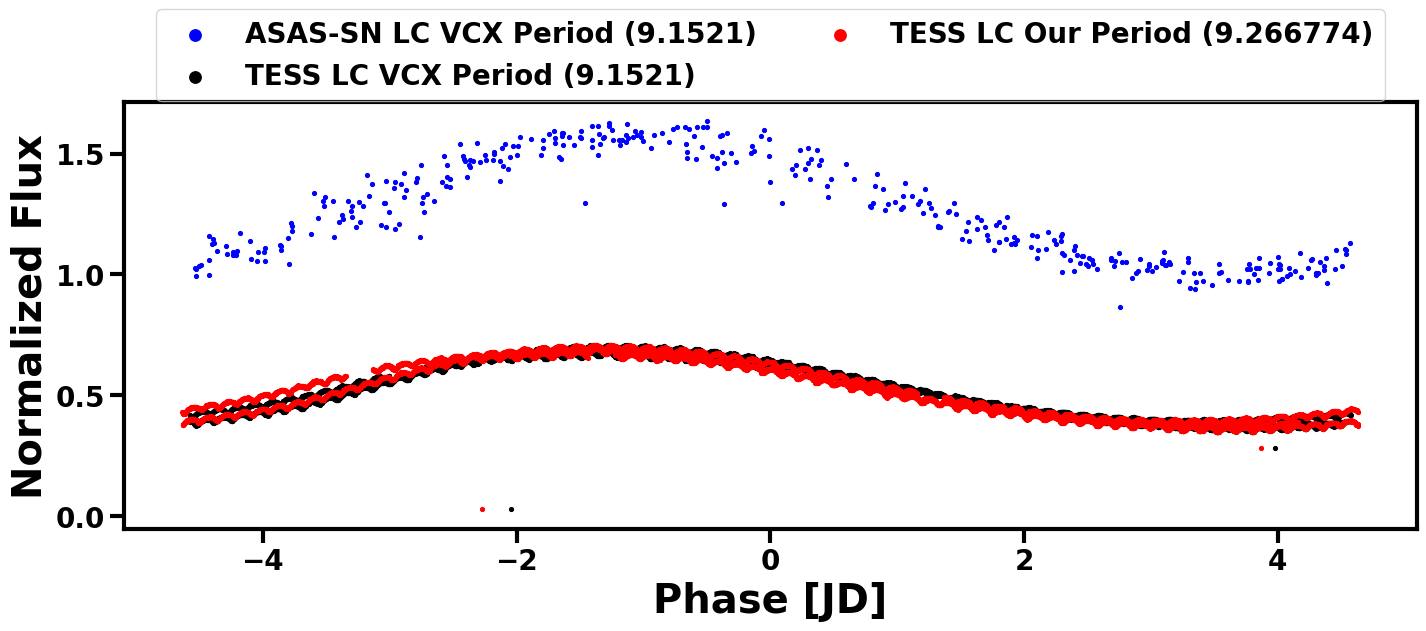

In [12]:
plotter = lcnormed.fold(period=9.1521) #them
tesslc = tesslc2.fold(period=9.1521, epoch_phase=3.2) # them
tesslc22 = tesslc2.fold(period=9.266774, epoch_phase=3.2) # them

fig, ax = plt.subplots(1, 1, figsize=(15, 7))
scat = plotter.scatter(ax = ax, s=30, label='ASAS-SN LC VCX Period (9.1521)', c='b', offset=0.25, rasterized=True)
scat = tesslc.scatter(ax = ax, s=30,label='TESS LC VCX Period (9.1521)', c='k', offset=-0.5, rasterized=True)
scat = tesslc22.scatter(ax = ax, s=30,label='TESS LC Our Period (9.266774)', c='r', offset=-0.5, rasterized=True)

ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('ceph_phasefold.pdf', dpi=300)

# 2. YSO

In [13]:
# ASAS-SN LC
lc = lk.LightCurve(time=dates[1], flux = fluxes[1], flux_err=errors[1])
lcnormedyso = lc.normalize().remove_outliers()

In [14]:
with fits.open("TIC220338773-YSO/hlsp_qlp_tess_ffi_s0033-0000000220338773_tess_v01_llc.fits") as hdul:
    yso33 = Table.read(hdul, format='fits').to_pandas()

with fits.open("TIC220338773-YSO/hlsp_qlp_tess_ffi_s0006-0000000220338773_tess_v01_llc.fits") as hdul:
    yso6 = Table.read(hdul, format='fits').to_pandas()

In [15]:
yso33flux = yso33['SAP_FLUX']
yso33days = yso33['TIME']
tesslcyso33 = lk.LightCurve(time=yso33days, flux = yso33flux).remove_outliers()


yso6flux = yso6['SAP_FLUX']
yso6days = yso6['TIME']
tesslcyso6 = lk.LightCurve(time=yso6days, flux = yso6flux).remove_outliers()

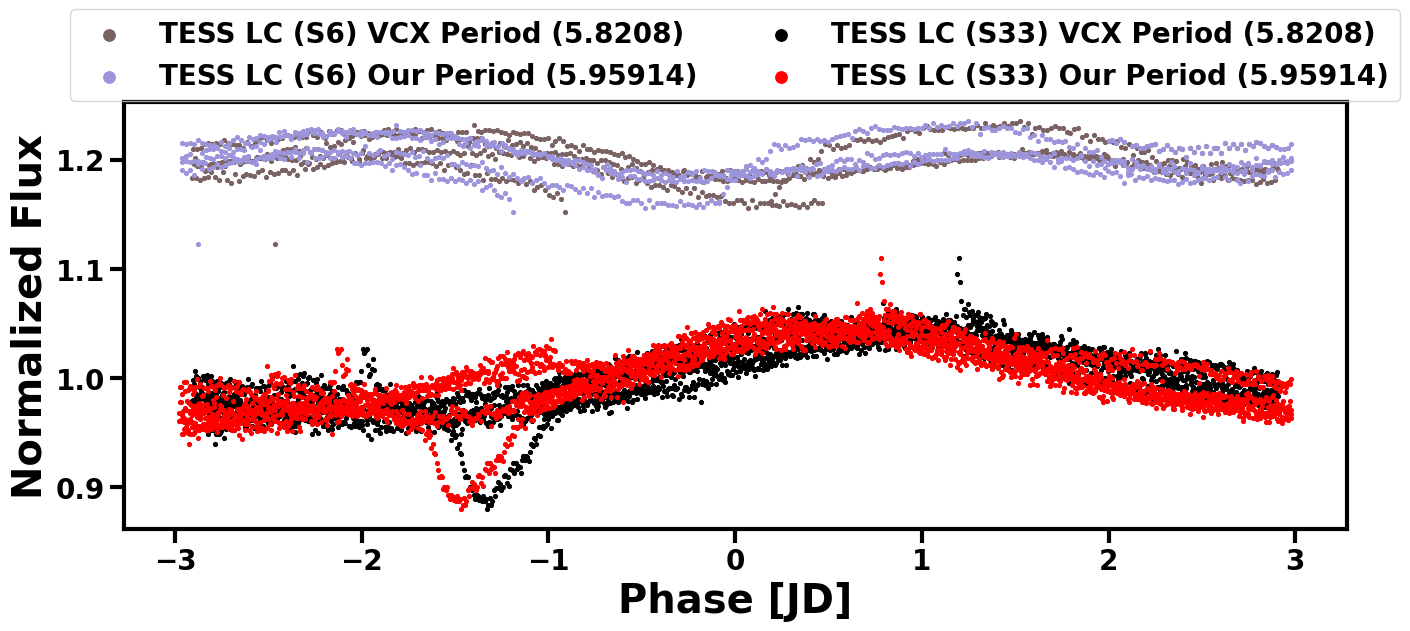

In [16]:
tesslcxcat = tesslcyso33.fold(period=5.8208, epoch_phase=3)# them
tesslcysouscat = tesslcyso33.fold(period=5.95914, epoch_phase=3) # us

tesslcxcats6 = tesslcyso6.fold(period=5.8208, epoch_phase=2) # them
tesslcysouscats6 = tesslcyso6.fold(period=5.95914, epoch_phase=2) # us

fig, ax = plt.subplots(1, 1, figsize=(15, 7))
                       
scat = tesslcxcats6.scatter(ax = ax, s=30, label='TESS LC (S6) VCX Period (5.8208)', c='#7A6263', offset=0.2, rasterized=True)
scat = tesslcysouscats6.scatter(ax = ax, s=30, label='TESS LC (S6) Our Period (5.95914)', c='#9C95DC',  offset=0.2, rasterized=True)

scat = tesslcxcat.scatter(ax = ax, s=30, label='TESS LC (S33) VCX Period (5.8208)', c='k', rasterized=True)
scat = tesslcysouscat.scatter(ax = ax, s=30, label='TESS LC (S33) Our Period (5.95914)', c='r', rasterized=True)
ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('yso_phasefold.pdf', dpi=300)

# 3. ROT

In [17]:
# ASAS-SN LC 
lc = lk.LightCurve(time=dates[2], flux = fluxes[2], flux_err=errors[2])
lcnormedrot = lc.normalize().remove_outliers()

In [18]:
with fits.open("TIC6129951-ROT/hlsp_qlp_tess_ffi_s0091-0000000006129951_tess_v01_llc.fits") as hdul:
    rot = Table.read(hdul, format='fits').to_pandas()

In [19]:
rotflux = rot['SAP_FLUX']
rotdays = rot['TIME']
tesslcrot = lk.LightCurve(time=rotdays, flux=rotflux).normalize().remove_outliers()

### Again, divide out the trend

In [20]:
rotdayline = rot['TIME']
xaxisrot = rotdayline
linfit_wlmodelrot = linfitter(model=wlmodel, x=[3778.766541, 3793.338474] , y=[1.085344, 1.169754])
wavelengths = linfit_wlmodelrot(xaxisrot)
linfit_wlmodelrot

<Linear1D(slope=0.00579264, intercept=-20.80370008)>

Text(0.5, 0, 'Time [BJD-2457000]')

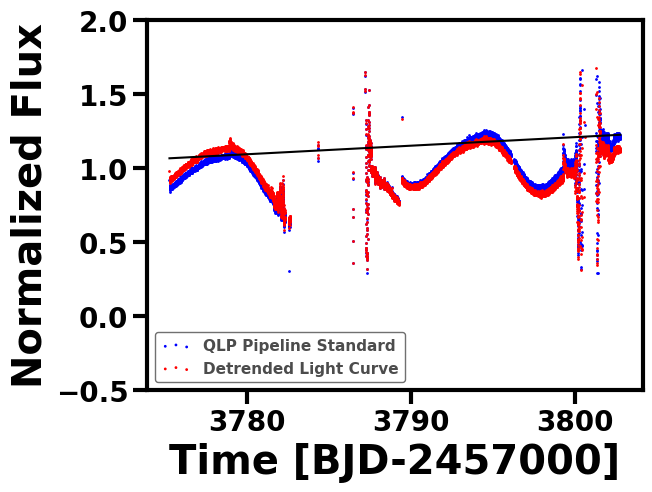

In [21]:
fig, ax = plt.subplots(1, 1)

fluxnew = rotflux/linfit_wlmodelrot(xaxisrot)
tesslcrot2 = lk.LightCurve(time=rotdays, flux=fluxnew).normalize().remove_outliers()

tesslcrot.scatter(ax=ax, c='b', label='QLP Pipeline Standard')
tesslcrot2.scatter(ax=ax, c='r', label='Detrended Light Curve')
plt.plot(xaxisrot, linfit_wlmodelrot(xaxisrot), c='k', label = 'Trend Line')

ax.set_ylim(-0.5, 2)
plt.xlabel(xlabel='Time [BJD-2457000]')

### Create sin waves to overplot at the periods (both VCX and ours)

In [22]:
amplitude = 0.1
period1 = 7.7504
period2 = 8.108467

B1 = 2 * np.pi / period1
B2 = 2 * np.pi / period2
# Create x-values
x = np.linspace(-4, 4, 1000)

# Calculate y-values
y1 = amplitude * np.sin(B1 * x)
y2 = amplitude * np.sin(B2 * (x-5)) #phase offset by 5 days to make the wave line up with the measurements

### Phase folded plot

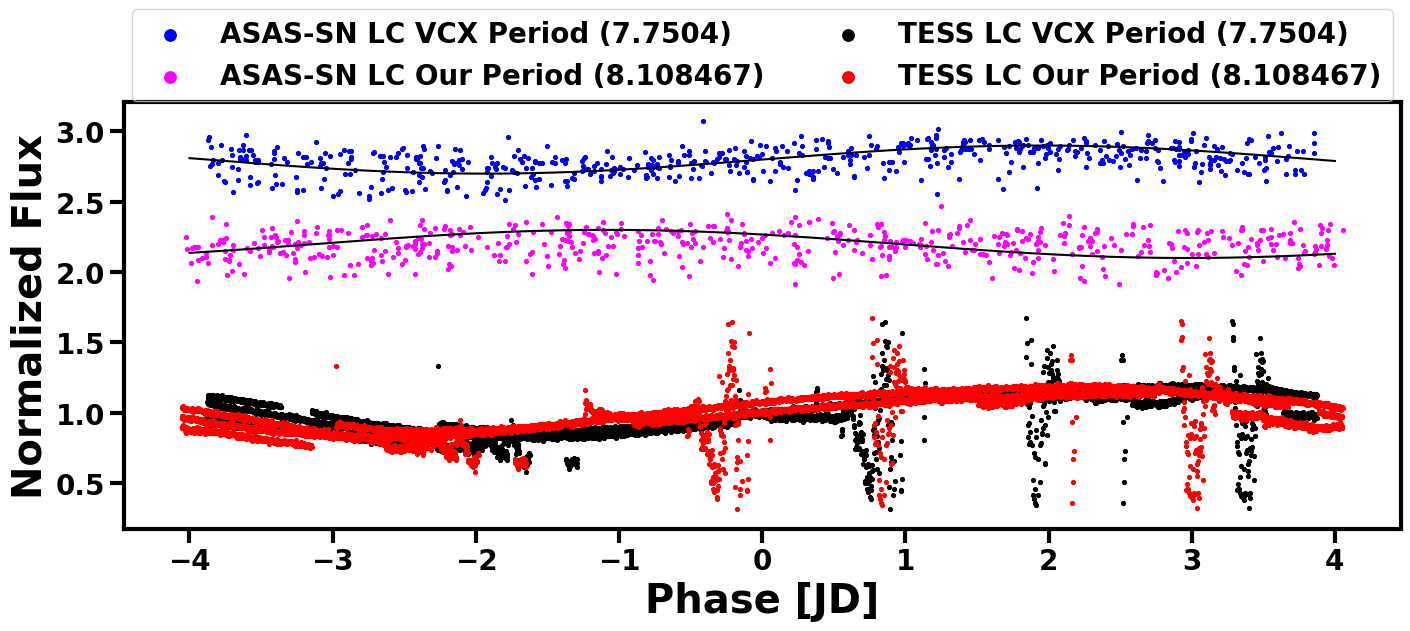

In [23]:
plotter = lcnormedrot.fold(period=7.7504) #them
plotter2 = lcnormedrot.fold(period=8.108467) #us
tesslcxcatrot = tesslcrot2.fold(period=7.7504, epoch_phase=-0.9) # them
tesslcuscatrot = tesslcrot2.fold(period=8.108467, epoch_phase=-0.9) # us

fig, ax = plt.subplots(1, 1, figsize=(15, 7))

scat = plt.plot(x, y1+2.8, 'k-', rasterized=True)
scat = plt.plot(x, y2+2.2, 'k-', rasterized=True)
scat = plotter.scatter(ax = ax,  s=30, label='ASAS-SN LC VCX Period (7.7504)', c='b', offset=1.8, rasterized=True)
scat = plotter2.scatter(ax = ax, s=30,label='ASAS-SN LC Our Period (8.108467)', c='magenta', offset=1.2, rasterized=True)

scat = tesslcxcatrot.scatter(ax = ax,s=30, label='TESS LC VCX Period (7.7504)', c='k', rasterized=True)
scat = tesslcuscatrot.scatter(ax = ax, s=30,label='TESS LC Our Period (8.108467)', c='r', rasterized=True)

ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('rot_phasefold.pdf', dpi=300)

# 4. EB-Algol Type

In [24]:
# ASAS-SN LC 
lc = lk.LightCurve(time=dates[3], flux = fluxes[3], flux_err=errors[3])
lcnormedeb = lc.normalize().remove_outliers()

In [25]:
with fits.open("TIC440850419-EA/hlsp_qlp_tess_ffi_s0045-0000000440850419_tess_v01_llc.fits") as hdul:
    eb = Table.read(hdul, format='fits').to_pandas()

In [26]:
tesslcflux = eb['SAP_FLUX']
tesslctime = eb['TIME']
tesslceb = lk.LightCurve(time=tesslctime, flux=tesslcflux).normalize().remove_outliers()

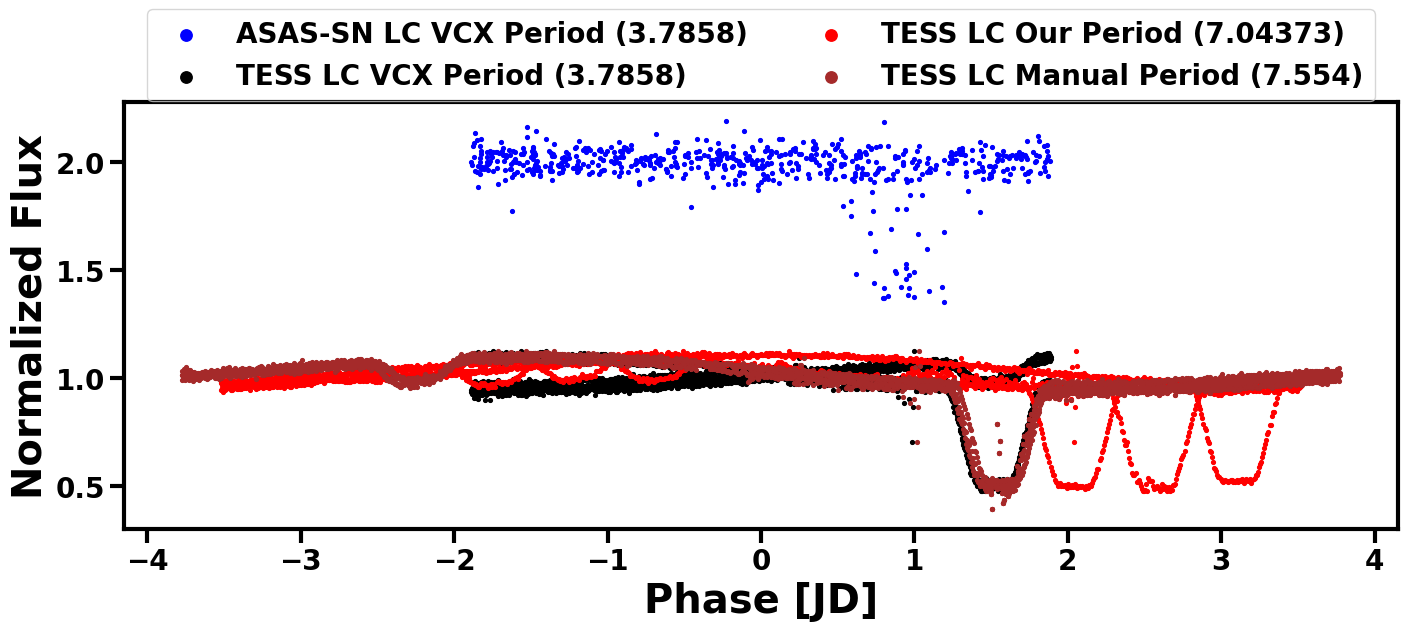

In [27]:
plotter = lcnormedeb.fold(period=3.7858, epoch_phase=1.5) #them
tesslcxcateb = tesslceb.fold(period= 3.7858, epoch_phase=1.5) # them
tesslcuscateb = tesslceb.fold(period=7.04373, epoch_phase=1.5) # us
tesslcmanualeb = tesslceb.fold(period=7.554, epoch_phase=1.5) # manual


fig, ax = plt.subplots(1, 1, figsize=(15, 7))


scat = plotter.scatter(ax = ax, s=30, label='ASAS-SN LC VCX Period (3.7858)', c='b', offset=1, rasterized=True)


scat = tesslcxcateb.scatter(ax = ax, s=30, label='TESS LC VCX Period (3.7858)', c='k', rasterized=True)
scat = tesslcuscateb.scatter(ax = ax, s=30, label='TESS LC Our Period (7.04373)', c='r', rasterized=True)
scat = tesslcmanualeb.scatter(ax = ax, s=30, label='TESS LC Manual Period (7.554)', c='brown', rasterized=True)
ax.set_ylabel('Normalized Flux', weight="bold")
ax.set_xlabel('Phase [JD]', weight="bold")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fancybox=True, markerscale=3)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('eb_phasefold.pdf', dpi=300)